<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [2]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-01-20 01:50:00--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.1’

survey-data.csv.1   100%[===================>] 152.13M  62.0MB/s    in 2.5s    

2026-01-20 01:50:07 (62.0 MB/s) - ‘survey-data.csv.1’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [3]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 76.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 69.1 MB/s eta 0:00:00


In [4]:
!pip install seaborn
import seaborn as sns

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [5]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [7]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [8]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [9]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [10]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [11]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [12]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


In [21]:
QUERY = """
SELECT CompTotal, COUNT(*) as occurrences
FROM main
GROUP BY CompTotal
ORDER BY occurrences DESC;
"""
df_comptl = pd.read_sql_query(QUERY, conn)
df_comptl.head()

,CompTotal,occurrences
0,NaN,31697
1,100000.0,939
2,60000.0,839
3,120000.0,793
4,80000.0,728


In [114]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


In [115]:
#df['CompTotal'].value_counts()

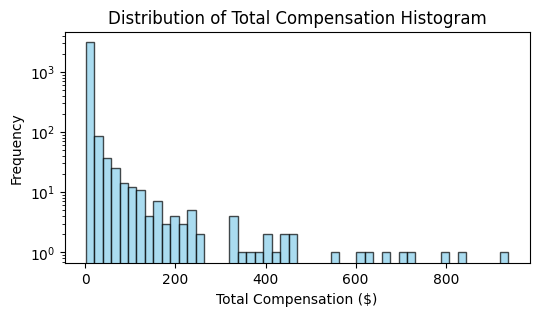

In [116]:
## Write your code here
plt.figure(figsize=(6,3))
df['CompTotal'].value_counts().plot(kind='hist', bins=50, logy=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Total Compensation Histogram')
plt.xlabel('Total Compensation ($)')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

**Box Plots**

Plot a box plot of Age.


<Axes: ylabel='Age'>

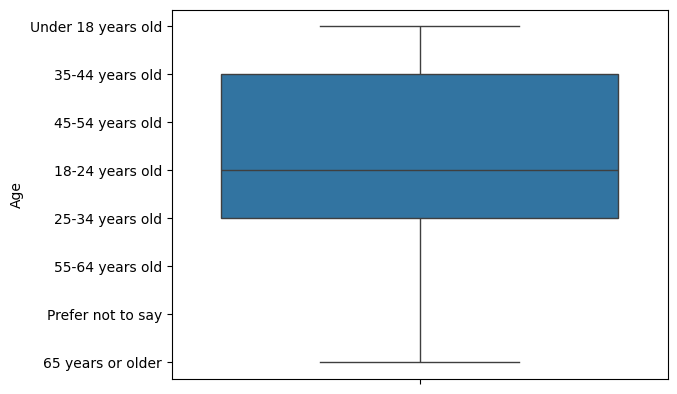

In [117]:
## Write your code here
sns.boxplot(data=df, y='Age', legend=False)

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


In [118]:
#df[['WorkExp', 'Age']].head()

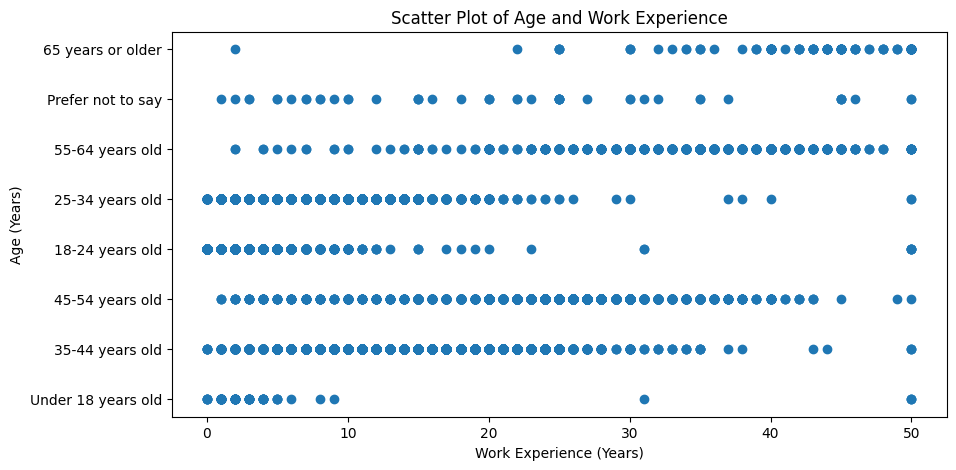

In [119]:
## Write your code here
plt.figure(figsize=(10, 5))
# Create the scatter plot
plt.scatter(data=df, x='WorkExp', y='Age')
# Add labels and a title for clarity
plt.title("Scatter Plot of Age and Work Experience")
plt.ylabel("Age (Years)")
plt.xlabel("Work Experience (Years)")
# Display the plot
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


In [120]:
df['Frustration'].value_counts()

Frustration
None of these                                                                                                                                                                                                                                              2364
Amount of technical debt                                                                                                                                                                                                                                   2067
Amount of technical debt;Reliability of tools/systems used in work                                                                                                                                                                                          831
Amount of technical debt;Complexity of tech stack for deployment;Complexity of tech stack for build                                                                                                                         

In [121]:
df['RemoteWork'].value_counts()

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

In [122]:
age_map = {
        'Under 18 years old': 0, 
        '18-24 years old': 1, 
        '25-34 years old': 2, 
        '35-44 years old': 3, 
        '45-54 years old': 4, 
        '55-64 years old': 5, 
        '65 years or older' : 6, 
        'Prefer not to say' : 7
    }
time_map = {
        'Less than 15 minutes a day' : 1,
        '15-30 minutes a day' : 2,
        '30-60 minutes a day': 3,
        '60-120 minutes a day' : 4,
        'Over 120 minutes a day' : 5
    }
rw_map = {
        'Hybrid (some remote, some in-person)' : 1,
        'Remote' : 2,
        'In-person' : 3
}
df['Age_Num'] = df['Age'].map(age_map)
df['Time_Num'] = df['TimeSearching'].map(time_map)
df['Rw_Num'] = df['RemoteWork'].map(rw_map)
# IMPORTANT: Remove or fill NaNs, as they cause the 'float' plotting error
df_clean = df.dropna(subset=['Age_Num', 'Time_Num', 'Rw_Num'])

In [151]:
#df_clean.head()

In [128]:
df_clean['Age_Num'].dtype

dtype('int64')

In [145]:
## Write your code here
size_multiplier = 50 
df_clean['AgeScaled'] = df_clean['Age_Num'] * size_multiplier
df_clean['AgeScaled'].head()

/tmp/ipykernel_299/776574436.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['AgeScaled'] = df_clean['Age_Num'] * size_multiplier


10    150
12    150
15    200
18    100
20    100
Name: AgeScaled, dtype: int64

In [146]:
df_clean['AgeScaled'].dtype

dtype('int64')

/tmp/ipykernel_299/291901514.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


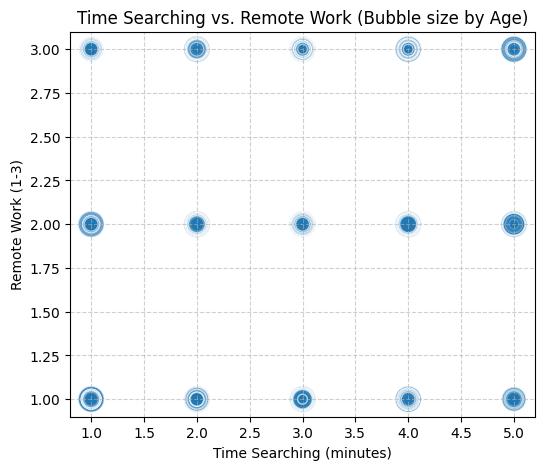

In [150]:
plt.figure(figsize=(6,5))
plt.scatter(
    data = df_clean,
    x='Time_Num',
    y='Rw_Num',
    s='AgeScaled',
    alpha=0.6,          # Adjust transparency
    edgecolor='w',      # Bubble edge color
    cmap='viridis'
)
# Add labels and title
plt.xlabel("Time Searching (minutes)")
plt.ylabel("Remote Work (1-3)")
plt.title("Time Searching vs. Remote Work (Bubble size by Age)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


In [152]:
## Write your code here
desired_db = df['DatabaseWantToWorkWith'].str.split(';').explode()
top_5_db = desired_db.value_counts().head(5)

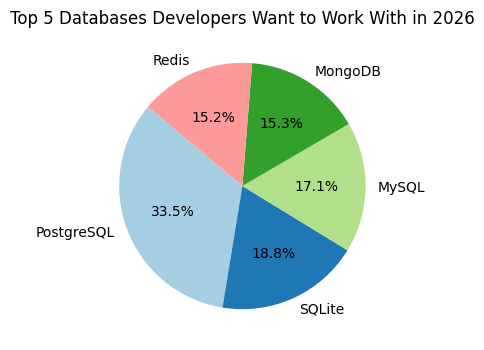

In [155]:
# 3. Create the pie chart
plt.figure(figsize=(6, 4))
plt.pie(top_5_db, labels=top_5_db.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Top 5 Databases Developers Want to Work With in 2026')
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


In [172]:
df['Time_Ans_Num'] = df['TimeAnswering'].map(time_map)
df_clean = df.dropna(subset=['Time_Ans_Num'])

In [182]:
#df_clean['Age_Num'].value_counts()

In [174]:
## Write your code here
filtered_df = df_clean[(df_clean['Age_Num'] == 2) | (df_clean['Age_Num'] == 3)]

In [179]:
#filtered_df.head()

In [176]:
median_data = filtered_df.groupby('Age_Num')[['Time_Num', 'Time_Ans_Num']].median()

In [177]:
median_data.head()

,Time_Num,Time_Ans_Num
Age_Num,,
2,3.0,2.0
3,3.0,3.0


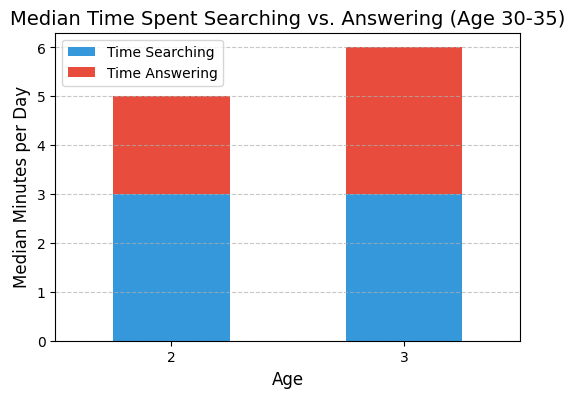

In [181]:
# 3. Plot the stacked bar chart
ax = median_data.plot(kind='bar', stacked=True, figsize=(6, 4), color=['#3498db', '#e74c3c'])
# 4. Formatting the chart
plt.title('Median Time Spent Searching vs. Answering (Age 30-35)', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Median Minutes per Day', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Time Searching', 'Time Answering'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visualizing Comparison of Data
**Line Chart**
Plot the median `CompTotal` for all ages from 45 to 60.

In [184]:
## Write your code here
df_filtered = df_clean[(df_clean['Age_Num'] == 4) | (df_clean['Age_Num'] == 5)] # 1. Filter the dataframe for ages 45 to 60

In [187]:
age_median_comp = df_filtered.groupby('Age_Num')['CompTotal'].median() # 2. Group by Age and calculate the median CompTotal

In [189]:
age_median_comp.transpose()

Age_Num
4    130000.0
5    140000.0
Name: CompTotal, dtype: float64

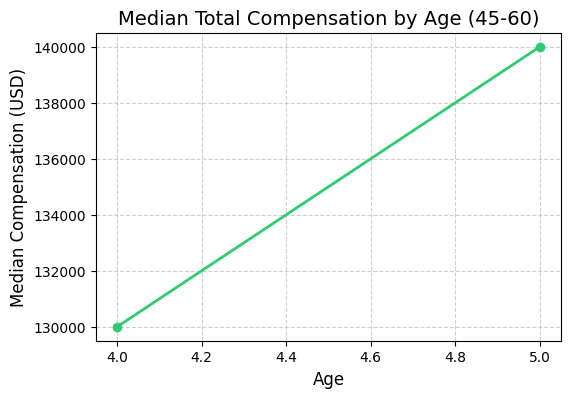

In [193]:
# 3. Plot the Line Chart
plt.figure(figsize=(6, 4))
age_median_comp.plot(kind='line', marker='o', color='#2ecc71', linewidth=2)
# 4. Formatting the chart
plt.title('Median Total Compensation by Age (45-60)', fontsize=14)
plt.ylabel('Median Compensation (USD)', fontsize=12)
plt.xlabel('Age', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


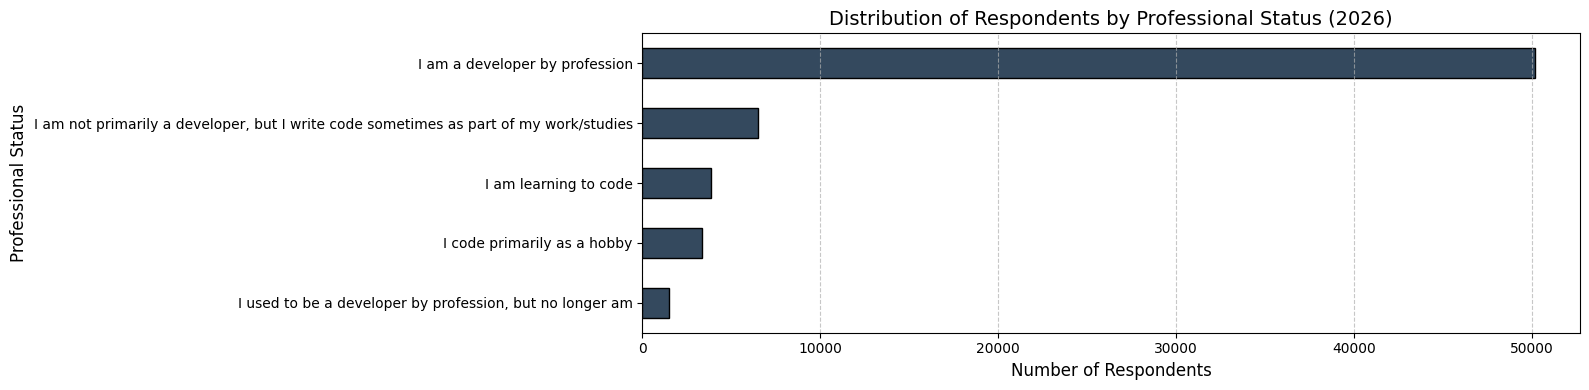

In [195]:
## Write your code here
# 1. Count the occurrences of each category in MainBranch
branch_counts = df['MainBranch'].value_counts()
# 2. Create the horizontal bar chart
plt.figure(figsize=(16,4))
branch_counts.plot(kind='barh', color='#34495e', edgecolor='black')
# 3. Formatting the chart
plt.title('Distribution of Respondents by Professional Status (2026)', fontsize=14)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Professional Status', fontsize=12)
plt.gca().invert_yaxis()  # Optional: Invert to show the largest group at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
